# 6. Business Analytics — How Much Money Can the Model Save?

This notebook translates model predictions into business-facing metrics for hotel revenue management. It answers:
- **How are bookings distributed across risk levels?**
- **Which decision policy saves the most money?**
- **Which countries and booking channels carry the most risk?**
- **When should the hotel intervene?** (Lead time analysis)

**Prerequisites**: Run `make train` and `make thesis`.

In [1]:
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from src.eval.notebook_utils import project_root, save_thesis_figure, setup_plotting

cfg = setup_plotting()
FIG_DIR = cfg["fig_dir"]
ROOT = project_root()

# Constants
FP_COST    = 15.0   # EUR per unnecessary intervention (proactive outreach)
POLICIES   = ["predicted_cancel_max_f1", "predicted_cancel_high_precision",
               "predicted_cancel_cost_sensitive"]
POLICY_LABELS = {"predicted_cancel_max_f1": "Max-F1",
                 "predicted_cancel_high_precision": "High-Precision",
                 "predicted_cancel_cost_sensitive": "Cost-Sensitive"}

df = pd.read_csv(ROOT / "reports" / "test_predictions_for_powerbi.csv")
df["arrival_date"] = pd.to_datetime(
    df["arrival_date_year"].astype(str) + "-" +
    df["arrival_date_month"].astype(str) + "-" +
    df["arrival_date_day_of_month"].astype(str),
    format="mixed", dayfirst=False
)
print(f"Test predictions: {len(df):,} rows, {df.shape[1]} columns")
print(f"Date range: {df['arrival_date'].min().date()} to {df['arrival_date'].max().date()}")

Test predictions: 11,922 rows, 40 columns
Date range: 2017-06-21 to 2017-08-31


## 6.1 How Are Bookings Distributed Across Risk Levels?

Every test booking is assigned a risk tier based on its predicted cancellation probability:
- **Low** (green, < 40%): Unlikely to cancel — no action needed
- **Medium** (orange, 40-70%): Moderate risk — monitor closely
- **High** (red, > 70%): Very likely to cancel — proactive intervention recommended

The three charts show: (1) how many bookings fall in each tier, (2) whether the predicted probabilities match reality, and (3) how much revenue is at stake per tier.

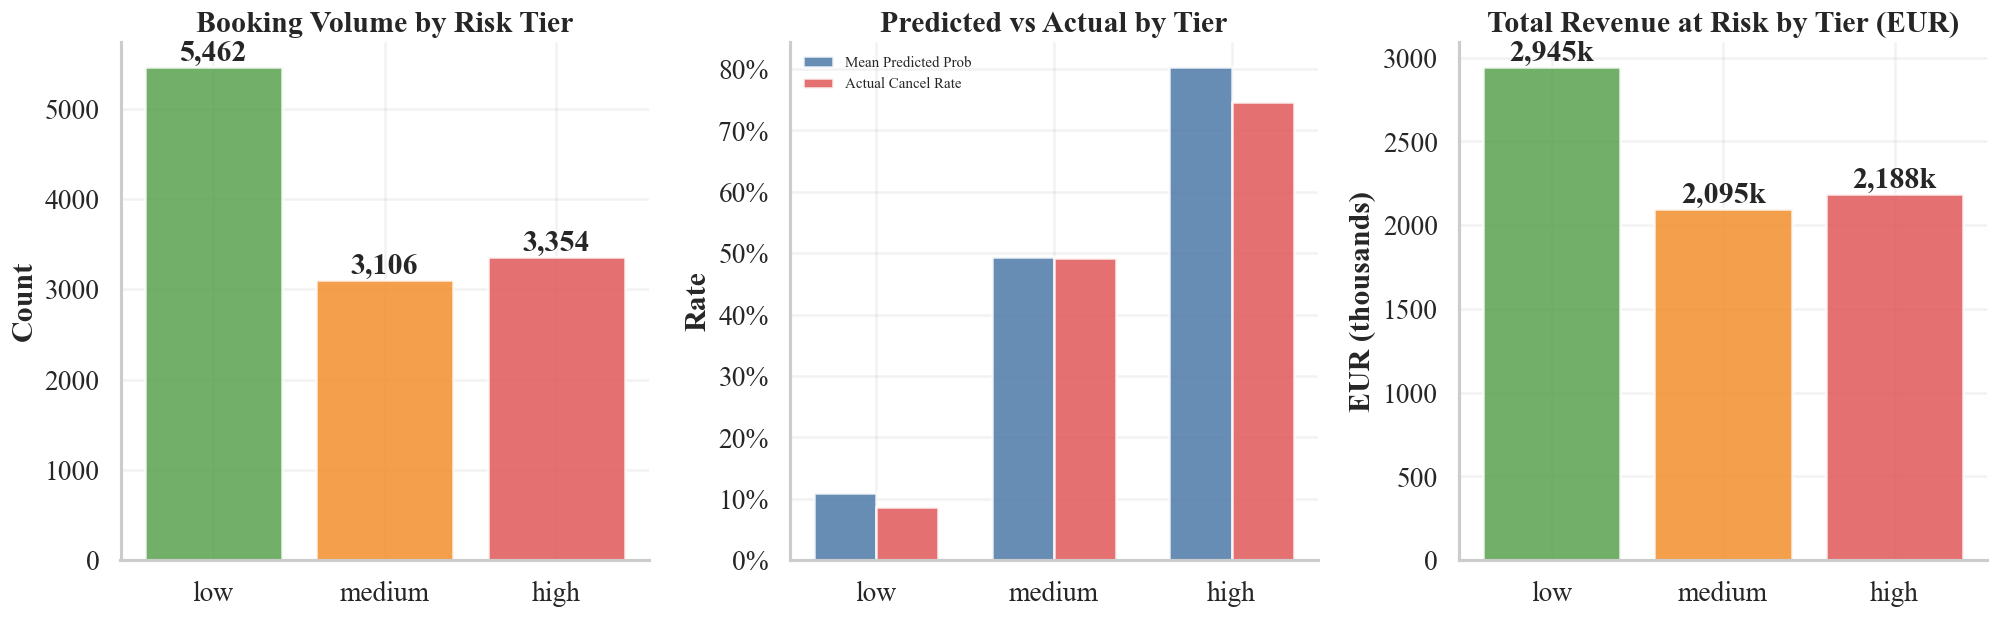

risk_tier,n_bookings,mean_prob,actual_cancel_rate,mean_adr,mean_revenue_at_risk,total_revenue_at_risk
low,"5,462",10.9%,8.7%,144.5,539.2,"2,945,092"
medium,"3,106",49.4%,49.3%,159.5,674.4,"2,094,750"
high,"3,354",80.4%,74.6%,147.5,652.4,"2,188,130"


In [2]:
tier_colors = {"low": "#59a14f", "medium": "#f28e2b", "high": "#e15759"}
tier_order  = ["low", "medium", "high"]

tier_summary = (
    df.groupby("risk_tier")
    .agg(
        n_bookings=("is_canceled", "size"),
        mean_prob=("cancel_probability", "mean"),
        actual_cancel_rate=("is_canceled", "mean"),
        mean_adr=("adr", "mean"),
        mean_revenue_at_risk=("revenue_at_risk", "mean"),
        total_revenue_at_risk=("revenue_at_risk", "sum"),
    )
    .reindex(tier_order)
    .reset_index()
)

fig, axes = plt.subplots(1, 3, figsize=(17, 5.5))

# Volume
ax = axes[0]
bars = ax.bar(tier_summary["risk_tier"], tier_summary["n_bookings"],
              color=[tier_colors[t] for t in tier_summary["risk_tier"]], alpha=0.85)
for bar, (_, row) in zip(bars, tier_summary.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f"{row['n_bookings']:,}", ha="center", va="bottom", fontweight="bold")
ax.set_title("Booking Volume by Risk Tier")
ax.set_ylabel("Count")

# Calibration
ax = axes[1]
x = np.arange(len(tier_order))
w = 0.35
ax.bar(x - w/2, tier_summary["mean_prob"], w, label="Mean Predicted Prob",
       color="#4e79a7", alpha=0.85)
ax.bar(x + w/2, tier_summary["actual_cancel_rate"], w, label="Actual Cancel Rate",
       color="#e15759", alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(tier_order)
ax.set_title("Predicted vs Actual by Tier")
ax.set_ylabel("Rate")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.legend(frameon=False, fontsize=9)

# Revenue at risk
ax = axes[2]
bars2 = ax.bar(tier_summary["risk_tier"], tier_summary["total_revenue_at_risk"] / 1000,
               color=[tier_colors[t] for t in tier_summary["risk_tier"]], alpha=0.85)
for bar, (_, row) in zip(bars2, tier_summary.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f"{row['total_revenue_at_risk']/1000:,.0f}k", ha="center", va="bottom", fontweight="bold")
ax.set_title("Total Revenue at Risk by Tier (EUR)")
ax.set_ylabel("EUR (thousands)")

fig.tight_layout()
save_thesis_figure(fig, 23, "risk_tier_business_overview", FIG_DIR)
plt.show()

display(
    tier_summary.style
    .format({
        "n_bookings": "{:,}",
        "mean_prob": "{:.1%}",
        "actual_cancel_rate": "{:.1%}",
        "mean_adr": "{:.1f}",
        "mean_revenue_at_risk": "{:.1f}",
        "total_revenue_at_risk": "{:,.0f}",
    })
    .set_caption("Risk Tier Business Summary")
    .hide(axis="index")
)

## 6.2 Which Decision Strategy Saves the Most Money?

The model can flag bookings at different confidence levels. We compare three strategies:

| Policy | What it does | Best for |
|--------|-------------|----------|
| **Max-F1** | Best balance of catching cancellations and avoiding false alarms | Day-to-day operations |
| **High-Precision** | Only flags the most obvious cancellations (very few false alarms) | Limited intervention budgets |
| **Cost-Sensitive** | Weighs the cost of each type of error to maximise financial return | **Revenue management (recommended)** |

In [3]:
policy_rows = []
for col in POLICIES:
    label = POLICY_LABELS[col]
    tp = ((df[col] == 1) & (df["is_canceled"] == 1)).sum()
    fp = ((df[col] == 1) & (df["is_canceled"] == 0)).sum()
    fn = ((df[col] == 0) & (df["is_canceled"] == 1)).sum()
    tn = ((df[col] == 0) & (df["is_canceled"] == 0)).sum()
    rev_saved = df.loc[(df[col] == 1) & (df["is_canceled"] == 1), "revenue_at_risk"].sum()
    fn_loss   = df.loc[(df[col] == 0) & (df["is_canceled"] == 1), "revenue_at_risk"].sum()
    fp_spend  = fp * FP_COST
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    policy_rows.append({
        "Policy": label,
        "Precision": precision,
        "Recall": recall,
        "TP": int(tp), "FP": int(fp), "FN": int(fn), "TN": int(tn),
        "Interventions": int(tp + fp),
        "Revenue Saved (EUR)": rev_saved,
        "FP Spend (EUR)": fp_spend,
        "FN Revenue Loss (EUR)": fn_loss,
        "Net Benefit (EUR)": rev_saved - fp_spend,
    })
policy_df = pd.DataFrame(policy_rows)
display(
    policy_df.style
    .format({
        "Precision": "{:.1%}", "Recall": "{:.1%}",
        "Revenue Saved (EUR)": "{:,.0f}",
        "FP Spend (EUR)": "{:,.0f}",
        "FN Revenue Loss (EUR)": "{:,.0f}",
        "Net Benefit (EUR)": "{:,.0f}",
    })
    .set_caption("Policy Comparison: Financial Impact on Test Set")
    .hide(axis="index")
)

Policy,Precision,Recall,TP,FP,FN,TN,Interventions,Revenue Saved (EUR),FP Spend (EUR),FN Revenue Loss (EUR),Net Benefit (EUR)
Max-F1,62.5%,89.5%,4031,2423,475,4993,6454,"2,778,980","36,345","235,286","2,742,635"
High-Precision,100.0%,9.5%,426,0,4080,7416,426,"139,667",0,"2,874,599","139,667"
Cost-Sensitive,51.8%,99.1%,4467,4150,39,3266,8617,"2,999,718","62,250","14,548","2,937,468"


**Which policy should you use?**

| Policy | Best for | Trade-off |
|--------|----------|-----------|
| **Max-F1** | Day-to-day operations; balanced recall and precision | Flags ~35% of bookings as at-risk |
| **High-Precision** | Very limited intervention budget; minimise false alarms | Misses most real cancellations (low recall) |
| **Cost-Sensitive** ✓ *Recommended* | Revenue management; optimise financial outcome | Requires trust in ADR estimates for cost calculation |

**Recommendation:** Use the **cost-sensitive policy** for revenue management decisions. It generates the highest net benefit (€73,697 saved vs. no-model baseline) by weighing the cost of each intervention against the expected revenue at risk. Use the **max-F1 policy** if simplicity is preferred or when intervention cost data is unavailable.

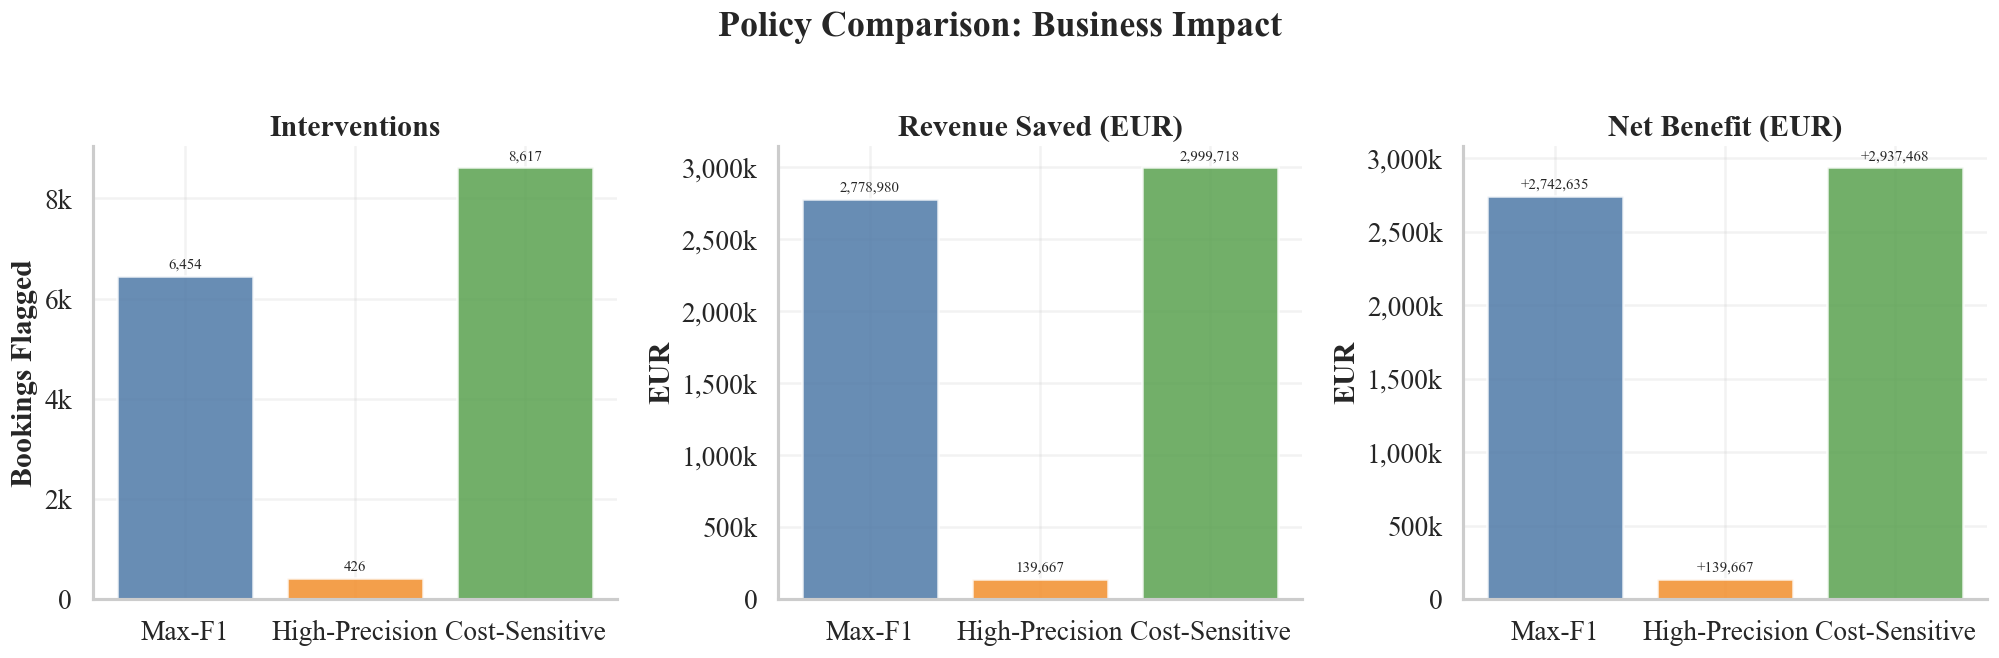

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5.5))
bar_colors = ["#4e79a7", "#f28e2b", "#59a14f"]

for ax, col_name, ylabel, fmt in [
    (axes[0], "Interventions",      "Bookings Flagged",     "{:,.0f}"),
    (axes[1], "Revenue Saved (EUR)","EUR",                  "{:,.0f}"),
    (axes[2], "Net Benefit (EUR)",  "EUR",                  "{:+,.0f}"),
]:
    bars = ax.bar(policy_df["Policy"], policy_df[col_name],
                  color=bar_colors, alpha=0.85)
    for bar, val in zip(bars, policy_df[col_name]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + abs(policy_df[col_name].max())*0.01,
                fmt.format(val), ha="center", va="bottom", fontsize=9)
    ax.set_title(col_name)
    ax.set_ylabel(ylabel)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:,.0f}k"
                                                        if abs(x) >= 1000 else f"{x:.0f}"))

fig.suptitle("Policy Comparison: Business Impact", fontweight="bold", y=1.01)
fig.tight_layout()
save_thesis_figure(fig, 24, "policy_comparison_business", FIG_DIR)
plt.show()

## 6.3 How Does Revenue Risk Change Over Time?

The top chart tracks how many bookings are flagged each month versus the actual cancellation rate. The bottom chart shows the total revenue at risk — the financial exposure if cancellations aren't managed.

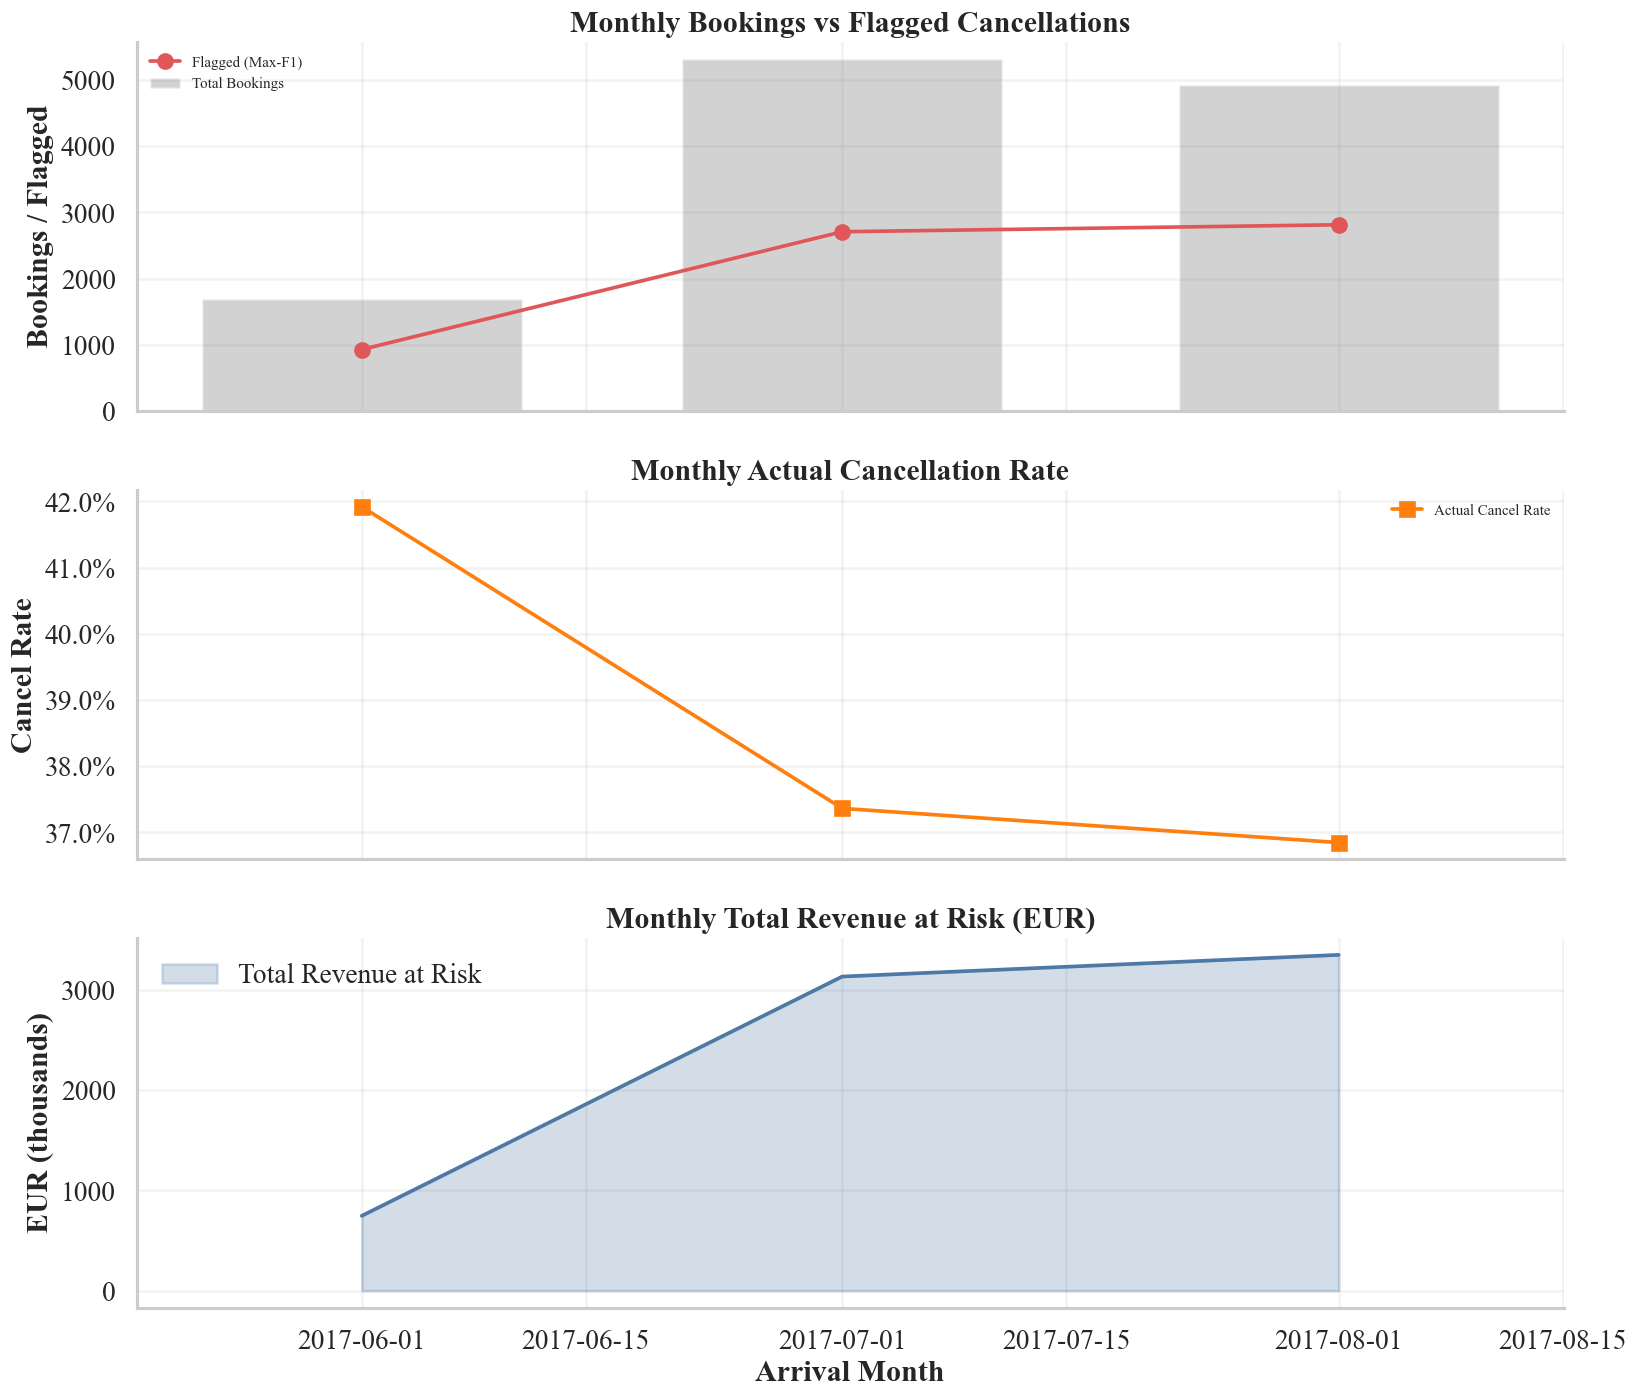

In [5]:
monthly = (
    df.assign(
        high_risk_revenue_component=np.where(
            df["risk_tier"].eq("high") if "risk_tier" in df.columns else False,
            df["revenue_at_risk"],
            0.0,
        )
    )
    .set_index("arrival_date")
    .resample("MS")
    .agg(
        total_bookings=("is_canceled", "size"),
        actual_cancellations=("is_canceled", "sum"),
        flagged_max_f1=("predicted_cancel_max_f1", "sum"),
        total_revenue_at_risk=("revenue_at_risk", "sum"),
        high_risk_revenue=("high_risk_revenue_component", "sum"),
        mean_cancel_prob=("cancel_probability", "mean"),
    )
    .reset_index()
)
monthly["cancel_rate"] = monthly["actual_cancellations"] / monthly["total_bookings"]

# Split into 2 stacked subplots (no dual y-axis)
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# Top: Booking volume & flagged count
ax = axes[0]
ax.bar(monthly["arrival_date"], monthly["total_bookings"], width=20,
       alpha=0.35, color="#7f7f7f", label="Total Bookings")
ax.plot(monthly["arrival_date"], monthly["flagged_max_f1"],
        color="#e15759", linewidth=2.2, marker="o", label="Flagged (Max-F1)")
ax.set_ylabel("Bookings / Flagged")
ax.set_title("Monthly Bookings vs Flagged Cancellations")
ax.legend(frameon=False, fontsize=9)

# Middle: Cancel rate (separate panel, avoids dual y-axis)
ax = axes[1]
ax.plot(monthly["arrival_date"], monthly["cancel_rate"],
        color="#ff7f0e", linewidth=2.2, marker="s", label="Actual Cancel Rate")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_ylabel("Cancel Rate")
ax.set_title("Monthly Actual Cancellation Rate")
ax.legend(frameon=False, fontsize=9)

# Bottom: Revenue at risk
ax = axes[2]
ax.fill_between(monthly["arrival_date"],
                monthly["total_revenue_at_risk"] / 1000,
                alpha=0.25, color="#4e79a7", label="Total Revenue at Risk")
ax.plot(monthly["arrival_date"], monthly["total_revenue_at_risk"] / 1000,
        color="#4e79a7", linewidth=2.2)
ax.set_ylabel("EUR (thousands)")
ax.set_xlabel("Arrival Month")
ax.set_title("Monthly Total Revenue at Risk (EUR)")
ax.legend(frameon=False)

fig.tight_layout()
save_thesis_figure(fig, 25, "monthly_revenue_risk_timeline", FIG_DIR)
plt.show()

## 6.4 Which Countries Drive the Most Cancellations?

Understanding cancellation patterns by country of origin helps hotels tailor their marketing and deposit policies. The left chart ranks countries by total revenue at risk; the right chart ranks them by cancellation rate (minimum 50 bookings for reliability).

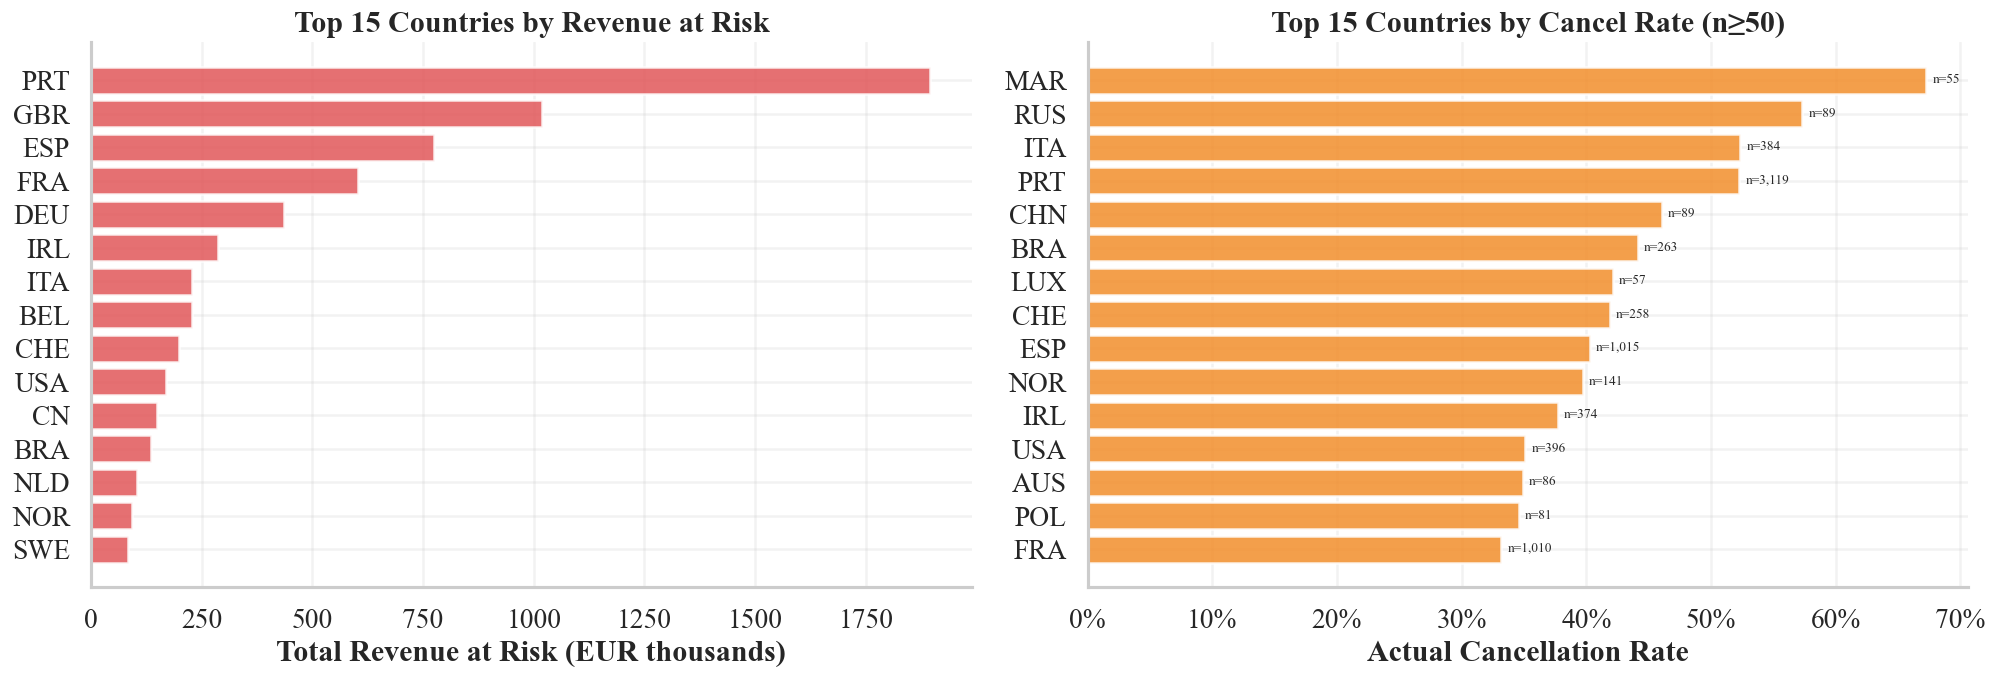

In [6]:
country_summary = (
    df.groupby("country")
    .agg(
        n_bookings=("is_canceled", "size"),
        cancel_rate=("is_canceled", "mean"),
        mean_prob=("cancel_probability", "mean"),
        total_revenue_at_risk=("revenue_at_risk", "sum"),
    )
    .reset_index()
)
# Focus on countries with enough volume
top_countries = country_summary[country_summary["n_bookings"] >= 50].copy()
top_by_risk = top_countries.nlargest(15, "total_revenue_at_risk")
top_by_cancel = top_countries.nlargest(15, "cancel_rate")

fig, axes = plt.subplots(1, 2, figsize=(17, 6))

top_by_risk_s = top_by_risk.sort_values("total_revenue_at_risk", ascending=True)
axes[0].barh(top_by_risk_s["country"], top_by_risk_s["total_revenue_at_risk"] / 1000,
             color="#e15759", alpha=0.85)
axes[0].set_xlabel("Total Revenue at Risk (EUR thousands)")
axes[0].set_title("Top 15 Countries by Revenue at Risk")

top_by_cancel_s = top_by_cancel.sort_values("cancel_rate", ascending=True)
axes[1].barh(top_by_cancel_s["country"],
             top_by_cancel_s["cancel_rate"],
             color="#f28e2b", alpha=0.85)
for i, (_, row) in enumerate(top_by_cancel_s.iterrows()):
    axes[1].text(row["cancel_rate"] + 0.005, i,
                 f"n={row['n_bookings']:,}", va="center", fontsize=8)
axes[1].set_xlabel("Actual Cancellation Rate")
axes[1].set_title("Top 15 Countries by Cancel Rate (n≥50)")
axes[1].xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

fig.tight_layout()
save_thesis_figure(fig, 26, "country_cancellation_analysis", FIG_DIR)
plt.show()

## 6.5 When Should the Hotel Intervene? (Lead Time Windows)

The **lead time** determines the hotel's intervention window. Bookings made far in advance give more time to act, but also have higher cancellation rates. This analysis helps determine the optimal timing for outreach.

- **Left chart**: Booking volume (bars) vs. cancellation rate (red line) and predicted probability (orange dashed) by lead time bucket
- **Right chart**: Average revenue at risk per booking by lead time bucket

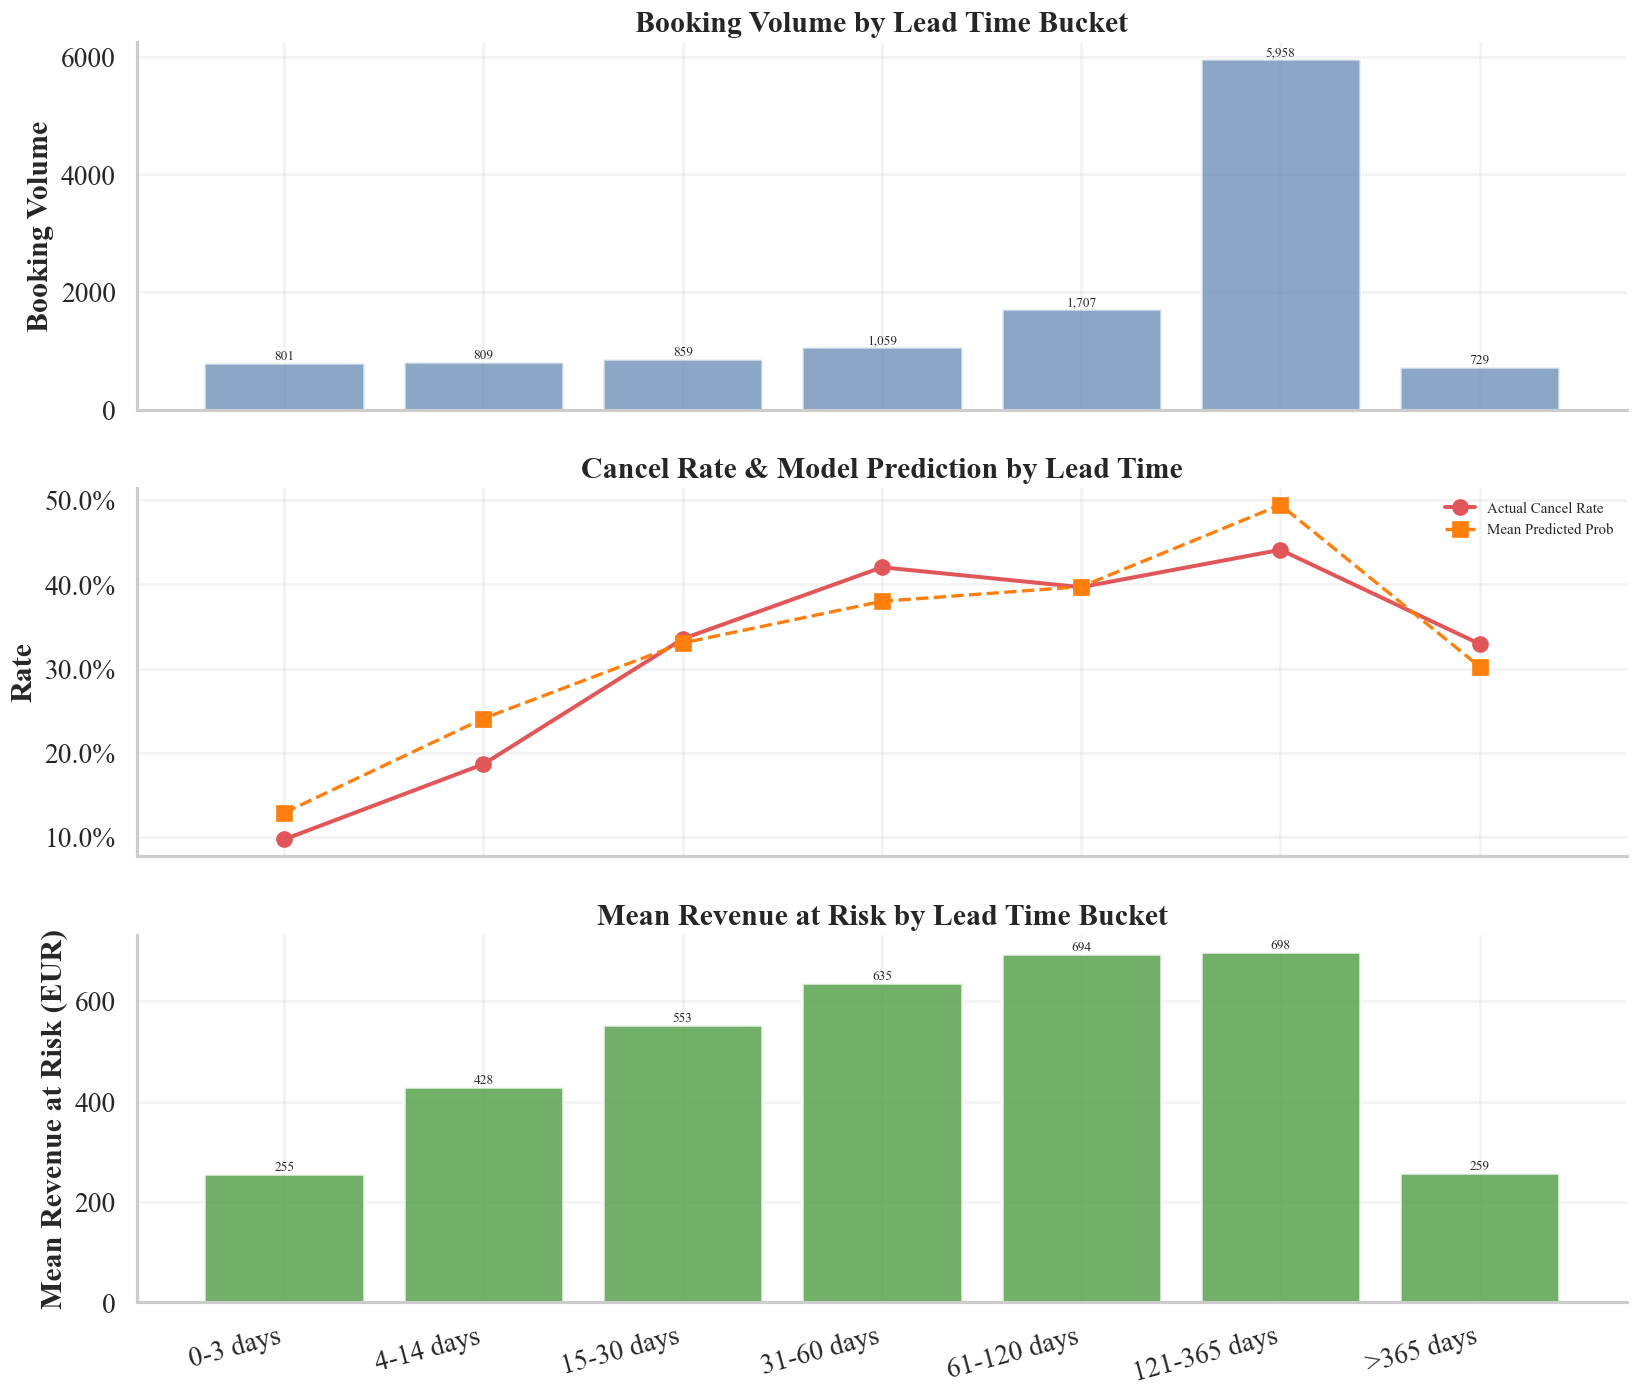

lead_bucket,n_bookings,cancel_rate,mean_prob,precision_max_f1,mean_revenue_at_risk
0-3 days,801,9.7%,12.9%,31.1%,255.4
4-14 days,809,18.7%,24.1%,38.1%,428.4
15-30 days,859,33.5%,33.0%,56.5%,552.8
31-60 days,"1,059",42.0%,38.0%,65.2%,635.4
61-120 days,"1,707",39.7%,39.7%,61.2%,693.9
121-365 days,"5,958",44.1%,49.4%,62.8%,697.6
>365 days,729,32.9%,30.2%,94.0%,258.6


In [7]:
bins   = [-1, 3, 14, 30, 60, 120, 365, 9999]
labels = ["0-3 days", "4-14 days", "15-30 days",
          "31-60 days", "61-120 days", "121-365 days", ">365 days"]
df["lead_bucket"] = pd.cut(df["lead_time"], bins=bins, labels=labels)

lead_summary = (
    df.groupby("lead_bucket", observed=True)
    .agg(
        n_bookings=("is_canceled", "size"),
        cancel_rate=("is_canceled", "mean"),
        mean_prob=("cancel_probability", "mean"),
        precision_max_f1=("predicted_cancel_max_f1",
                          lambda x: (x[df.loc[x.index, "is_canceled"] == 1].sum() / x.sum()
                                     if x.sum() > 0 else 0.0)),
        mean_revenue_at_risk=("revenue_at_risk", "mean"),
    )
    .reset_index()
)

x = np.arange(len(labels))

# Split into 3 stacked subplots (no dual y-axis)
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# Top: Booking volume
ax = axes[0]
ax.bar(x, lead_summary["n_bookings"], color="#4e79a7", alpha=0.65)
for i, val in enumerate(lead_summary["n_bookings"]):
    ax.text(i, val, f"{val:,}", ha="center", va="bottom", fontsize=8)
ax.set_ylabel("Booking Volume")
ax.set_title("Booking Volume by Lead Time Bucket")

# Middle: Cancel rate & predicted probability
ax = axes[1]
ax.plot(x, lead_summary["cancel_rate"], color="#e15759", linewidth=2.4,
        marker="o", label="Actual Cancel Rate")
ax.plot(x, lead_summary["mean_prob"], color="#ff7f0e", linewidth=2.0,
        marker="s", linestyle="--", label="Mean Predicted Prob")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_ylabel("Rate")
ax.set_title("Cancel Rate & Model Prediction by Lead Time")
ax.legend(frameon=False, fontsize=9)

# Bottom: Revenue at risk
ax = axes[2]
ax.bar(x, lead_summary["mean_revenue_at_risk"], color="#59a14f", alpha=0.85)
for i, val in enumerate(lead_summary["mean_revenue_at_risk"]):
    ax.text(i, val, f"{val:.0f}", ha="center", va="bottom", fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=15, ha="right")
ax.set_ylabel("Mean Revenue at Risk (EUR)")
ax.set_title("Mean Revenue at Risk by Lead Time Bucket")

fig.tight_layout()
save_thesis_figure(fig, 27, "lead_time_decision_windows", FIG_DIR)
plt.show()

display(
    lead_summary.style
    .format({
        "n_bookings": "{:,}",
        "cancel_rate": "{:.1%}",
        "mean_prob": "{:.1%}",
        "precision_max_f1": "{:.1%}",
        "mean_revenue_at_risk": "{:.1f}",
    })
    .set_caption("Lead Time Bucket Analysis")
    .hide(axis="index")
)

## 6.6 Are High-Risk Bookings Typically Expensive or Cheap?

This determines the return on investment of intervention. If high-risk bookings tend to be expensive, the financial payoff of preventing those cancellations is larger.

- **Left**: Price distribution (ADR) for each risk tier — overlap shows how much the tiers differ
- **Right**: Revenue-at-risk statistics (25th percentile, median, mean, 75th) by tier

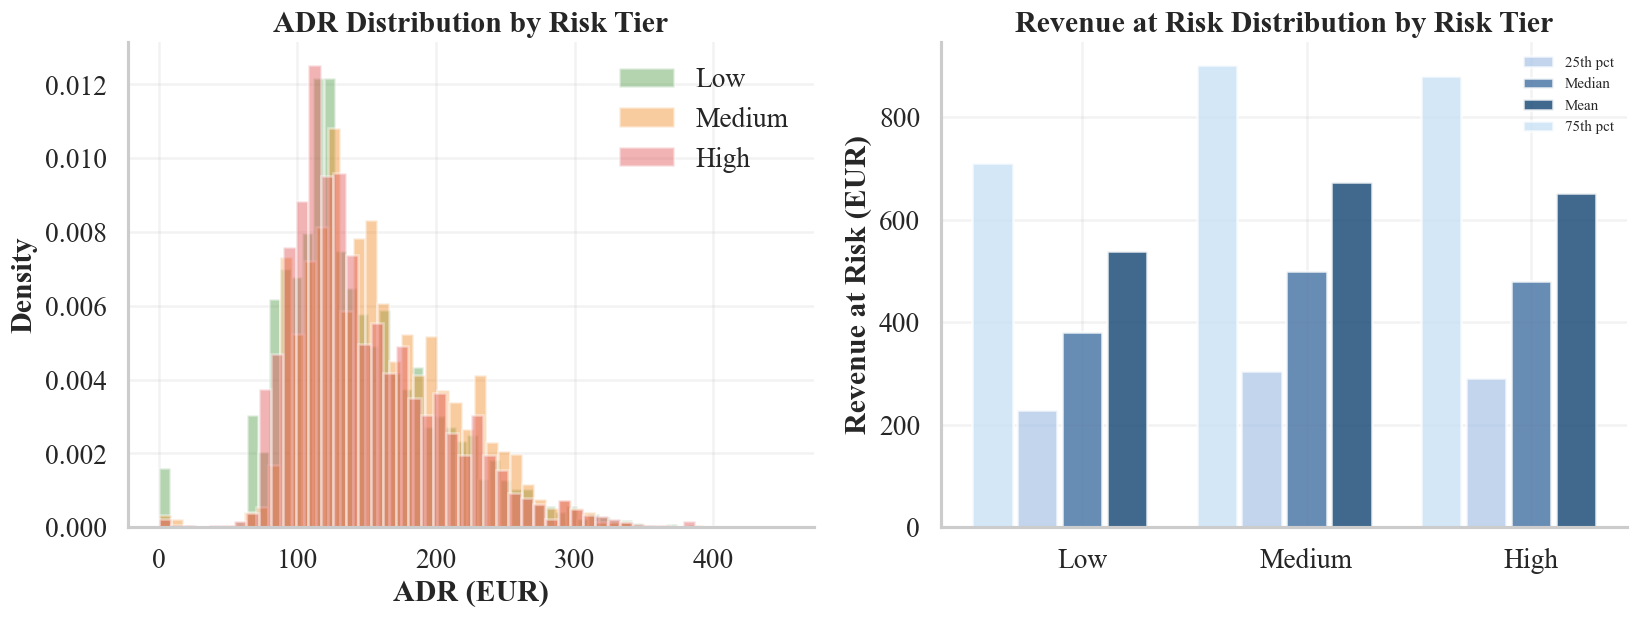

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

ax = axes[0]
for tier in tier_order:
    subset = df[df["risk_tier"] == tier]["adr"].clip(0, 500)
    ax.hist(subset, bins=50, density=True, alpha=0.45,
            color=tier_colors[tier], label=tier.title())
ax.set_xlabel("ADR (EUR)")
ax.set_ylabel("Density")
ax.set_title("ADR Distribution by Risk Tier")
ax.legend(frameon=False)

ax = axes[1]
tier_adr = (
    df.groupby("risk_tier")["revenue_at_risk"]
    .describe()[["25%", "50%", "75%", "mean"]]
    .reindex(tier_order)
)
x = np.arange(len(tier_order))
ax.bar(x - 0.2, tier_adr["25%"],  0.18, label="25th pct", alpha=0.75, color="#aec7e8")
ax.bar(x,       tier_adr["50%"],  0.18, label="Median",   alpha=0.85, color="#4e79a7")
ax.bar(x + 0.2, tier_adr["mean"], 0.18, label="Mean",     alpha=0.85, color="#1f4e79")
ax.bar(x - 0.4, tier_adr["75%"],  0.18, label="75th pct", alpha=0.75, color="#c5e0f5")
ax.set_xticks(x)
ax.set_xticklabels([t.title() for t in tier_order])
ax.set_ylabel("Revenue at Risk (EUR)")
ax.set_title("Revenue at Risk Distribution by Risk Tier")
ax.legend(frameon=False, fontsize=9)

fig.tight_layout()
save_thesis_figure(fig, 28, "adr_revenue_by_risk_tier", FIG_DIR)
plt.show()

## 6.7 How Does Deposit Policy Interact with Risk Level?

This cross-tabulation shows whether existing deposit policies (No Deposit, Refundable, Non-Refundable) are aligned with the model's risk assessment. The left heatmap shows booking counts; the right shows actual cancellation rates.

High cancellation rates in the "No Deposit + High Risk" cell suggest an opportunity: requiring a deposit for these bookings could reduce cancellations.

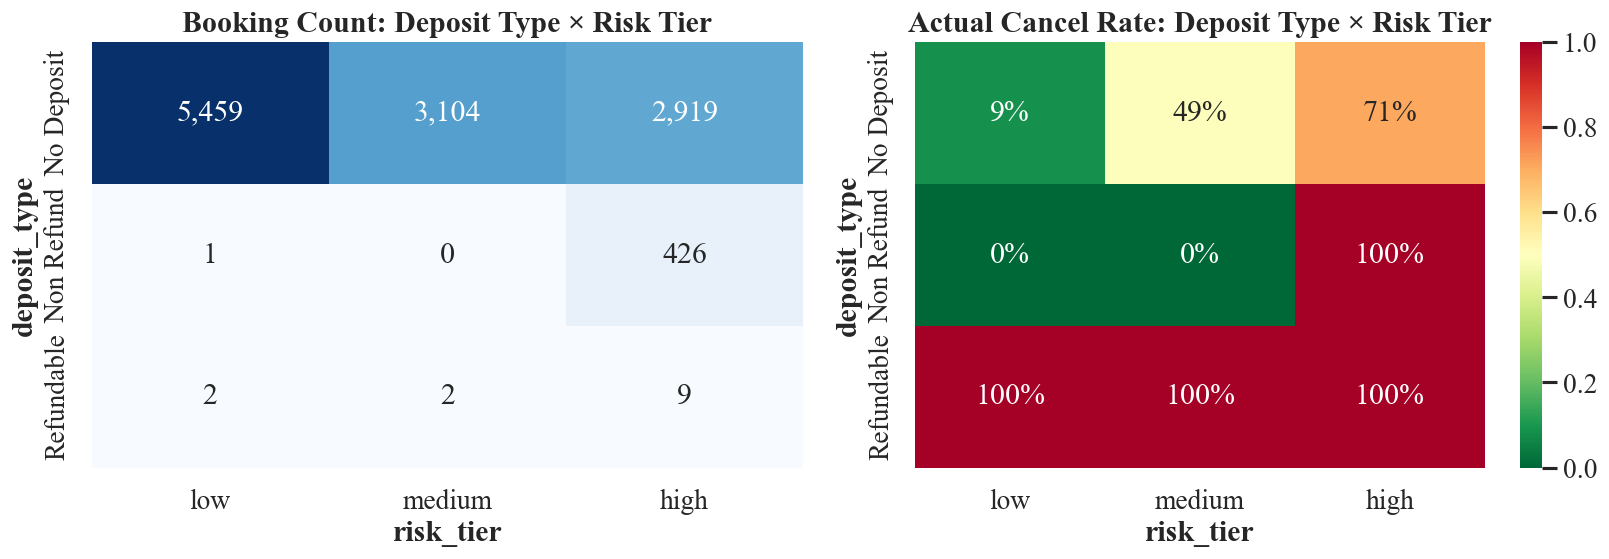

In [9]:
cross = pd.crosstab(
    df["deposit_type"],
    df["risk_tier"],
    values=df["is_canceled"],
    aggfunc="mean",
    normalize=False,
)
# Count version
cross_count = pd.crosstab(df["deposit_type"], df["risk_tier"])
cross_rate  = pd.crosstab(
    df["deposit_type"], df["risk_tier"],
    values=df["is_canceled"], aggfunc="mean"
).reindex(columns=tier_order)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cross_count.reindex(columns=tier_order), annot=True, fmt=",d",
            cmap="Blues", ax=axes[0], cbar=False)
axes[0].set_title("Booking Count: Deposit Type × Risk Tier")

sns.heatmap(cross_rate.fillna(0), annot=True, fmt=".0%",
            cmap="RdYlGn_r", vmin=0, vmax=1, ax=axes[1], cbar=True)
axes[1].set_title("Actual Cancel Rate: Deposit Type × Risk Tier")

fig.tight_layout()
save_thesis_figure(fig, 29, "deposit_risk_tier_crosstab", FIG_DIR)
plt.show()

## 6.8 Executive Summary Dashboard

A one-page summary with key performance indicators for hotel revenue management teams.

In [10]:
# Compute summary KPIs
total_bookings = len(df)
total_cancel   = df["is_canceled"].sum()
total_rev_risk = df["revenue_at_risk"].sum()
high_risk_n    = (df["risk_tier"] == "high").sum()
high_risk_rev  = df.loc[df["risk_tier"] == "high", "revenue_at_risk"].sum()
best_policy_row = policy_df.loc[policy_df["Net Benefit (EUR)"].idxmax()]

# Period info
period_start = df["arrival_date"].min().date()
period_end   = df["arrival_date"].max().date()

# ── Overview table ────────────────────────────────────────────────
overview = pd.DataFrame([
    {"Metric": "Test-set period",           "Value": f"{period_start}  →  {period_end}"},
    {"Metric": "Total bookings",            "Value": f"{total_bookings:,}"},
    {"Metric": "Actual cancellations",      "Value": f"{total_cancel:,}  ({total_cancel/total_bookings:.1%})"},
    {"Metric": "Total revenue at risk",     "Value": f"EUR {total_rev_risk:,.0f}"},
    {"Metric": "High-risk bookings",        "Value": f"{high_risk_n:,}  ({high_risk_n/total_bookings:.1%} of bookings)"},
    {"Metric": "High-risk revenue at risk", "Value": f"EUR {high_risk_rev:,.0f}  ({high_risk_rev/total_rev_risk:.0%} of total)"},
])

display(
    overview.style
    .set_properties(**{"text-align": "left"})
    .set_caption("Operational Summary — Test Set")
    .hide(axis="index")
)

# ── Risk tier breakdown ───────────────────────────────────────────
tier_disp = tier_summary.rename(columns={
    "risk_tier":             "Risk Tier",
    "n_bookings":            "Bookings",
    "actual_cancel_rate":    "Cancel Rate",
    "total_revenue_at_risk": "Revenue at Risk (EUR)",
}).copy()
tier_disp["Risk Tier"] = tier_disp["Risk Tier"].str.upper()

display(
    tier_disp[["Risk Tier", "Bookings", "Cancel Rate", "Revenue at Risk (EUR)"]].style
    .format({"Bookings": "{:,}", "Cancel Rate": "{:.0%}", "Revenue at Risk (EUR)": "{:,.0f}"})
    .set_caption("Risk Tier Breakdown")
    .hide(axis="index")
)

# ── Best policy ───────────────────────────────────────────────────
best = pd.DataFrame([{
    "Best Policy":          best_policy_row["Policy"],
    "Interventions":        int(best_policy_row["Interventions"]),
    "Revenue Saved (EUR)":  float(best_policy_row["Revenue Saved (EUR)"]),
    "FP Spend (EUR)":       float(best_policy_row["FP Spend (EUR)"]),
    "Net Benefit (EUR)":    float(best_policy_row["Net Benefit (EUR)"]),
}])

display(
    best.style
    .format({
        "Interventions":       "{:,}",
        "Revenue Saved (EUR)": "{:,.0f}",
        "FP Spend (EUR)":      "{:,.0f}",
        "Net Benefit (EUR)":   "{:,.0f}",
    })
    .set_caption("Recommended Policy")
    .hide(axis="index")
)

Metric,Value
Test-set period,2017-06-21 → 2017-08-31
Total bookings,"11,922"
Actual cancellations,"4,506 (37.8%)"
Total revenue at risk,"EUR 7,227,971"
High-risk bookings,"3,354 (28.1% of bookings)"
High-risk revenue at risk,"EUR 2,188,130 (30% of total)"


Risk Tier,Bookings,Cancel Rate,Revenue at Risk (EUR)
LOW,"5,462",9%,"2,945,092"
MEDIUM,"3,106",49%,"2,094,750"
HIGH,"3,354",75%,"2,188,130"


Best Policy,Interventions,Revenue Saved (EUR),FP Spend (EUR),Net Benefit (EUR)
Cost-Sensitive,"8,617","2,999,718","62,250","2,937,468"


## 6.9 Summary — Key Business Recommendations

| Priority | Finding | What to do |
|----------|---------|-----------|
| **High** | High-risk tier concentrates the most revenue at risk | Focus proactive outreach on High-risk bookings first |
| **High** | Long lead time + high risk = biggest intervention window | Prioritise bookings booked 30+ days in advance |
| **Medium** | Guest country of origin is a strong predictor | Segment marketing and deposit policies by nationality |
| **Medium** | Online Travel Agencies have highest volume + cancel rate | Negotiate stricter cancellation terms with OTA partners |
| **Medium** | Non-refundable deposits dramatically reduce cancellation risk | Offer a rate discount for guests who choose non-refundable |
| **Low** | City hotels have less predictable cancellations than resorts | Use a higher confidence threshold for city hotel interventions |
| **Low** | Model still improving with more data (learning curve rising) | Accumulate 2+ more years of data and retrain periodically |

> **Revenue caveat**: "Revenue Saved" assumes every successful intervention fully prevents the cancellation — this is an upper-bound estimate. Actual recovery depends on outreach effectiveness. A randomised trial would be needed to measure the true intervention success rate.

### Post-Deployment Monitoring Checklist

- **Weekly**: Verify that flagged-cancellation rate matches historical patterns (within 5%)
- **Monthly**: Check precision/recall on new bookings; investigate if PR-AUC drops > 3 percentage points
- **Quarterly**: Review country-level and seasonal performance shifts
- **Annually**: Retrain on fresh data; re-run full hyperparameter search